In [2]:
from google.colab import files

# Kaggle API anahtarınızı yükleyin (kaggle.json dosyası)
files.upload()

# Anahtarı doğru dizine taşıyın ve izinleri ayarlayın
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [1]:
# Dataseti indirin (URL: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)
!kaggle datasets download -d fedesoriano/stroke-prediction-dataset

# Zip dosyasını açın
!unzip stroke-prediction-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
License(s): copyright-authors
  0% 0.00/67.4k [00:00<?, ?B/s]
100% 67.4k/67.4k [00:00<00:00, 42.9MB/s]
Archive:  stroke-prediction-dataset.zip
  inflating: healthcare-dataset-stroke-data.csv  


In [3]:
!ls  # healthcare-dataset-stroke-data.csv dosyasını göreceksiniz

healthcare-dataset-stroke-data.csv  sample_data  stroke-prediction-dataset.zip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
"""
standartScaler
DecisionTree
Pipeline(standartScaler, DecisionTree)
"""

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [5]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
df = df.drop("id", axis=1)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [8]:
describe = df.describe()
describe

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


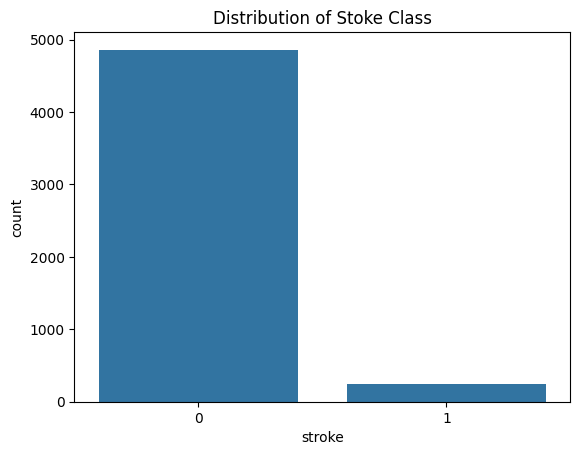

In [9]:
plt.figure()
sns.countplot(x="stroke",data=df)
plt.title("Distribution of Stoke Class")
plt.show()

In [10]:
"""
Dengesiz veri seti
4800 -> 0
250 -> 1

kcy: tüm sonuçlara 0 de ACC: 4800/(5100) = 0.94 Yanıltıcı sonuç
yanılmamak için:
-cm
-f1 score
Dengesiz veri seti cözümü:
-stoke (1) sayısı arttırmamız lazım, veri toplama
- down sampling (0) sayısını azalt, veri kaybı olur
"""

'\nDengesiz veri seti\n4800 -> 0\n250 -> 1\n\nkcy: tüm sonuçlara 0 de ACC: 4800/(5100) = 0.94 Yanıltıcı sonuç\nyanılmamak için:\n-cm\n-f1 score\nDengesiz veri seti cözümü:\n-stoke (1) sayısı arttırmamız lazım, veri toplama\n- down sampling (0) sayısını azalt, veri kaybı olur\n'

In [11]:
# Missing Value: DecisionTreeRegressor

df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [12]:
DT_bmi_pipe = Pipeline([
    ("scaler", StandardScaler()), # veriyi standartlaştırmak için standart scaler
    ("dtr", DecisionTreeRegressor()) # karar ağacı regresyon modeli
])


In [13]:
X = df[["gender","age","bmi"]].copy()

In [14]:
# gender sütununda bulunan değerleri sayısal değerlere dönüştürüyoruz
# male -> 0, female -> 1, other -> -1
X.gender = X.gender.map({"Male":0, "Female":1, "Other":-1}).astype(np.uint8)

In [15]:
# bmi değeri eksik olan NaN satırları ayır
missing = X[X.bmi.isna()]

In [16]:
# bmi değeri eksik olmayan verileri ayıralım
X = X[~X.bmi.isna()]
y = X.pop("bmi")

In [17]:
# modeli eksik olmayan veriler ile eğit
DT_bmi_pipe.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()), ('dtr', DecisionTreeRegressor())])

In [18]:
# eksik bmi değelerini tahmin edelim, tahmin yapılırken gender ve age kullanılacak
predicted_bmi = pd.Series(DT_bmi_pipe.predict(missing[["gender","age"]]), index=missing.index)

df.loc[missing.index, "bmi"] = predicted_bmi

In [19]:
# Model prediction: encoding,training and testing
df["gender"] = df["gender"].replace({"Male":0, "Female":1, "Other":-1}).astype(np.uint8)
df["Residence_type"] = df["Residence_type"].replace({"Urban":0, "Rural":1}).astype(np.uint8)
df["work_type"] = df["work_type"].replace({"Private":0, "Self-employed":1, "children":-1, "Govt_job":2, "Never_worked":-2}).astype(np.uint8)

<ipython-input-19-2e973d6a9794>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"] = df["gender"].replace({"Male":0, "Female":1, "Other":-1}).astype(np.uint8)
<ipython-input-19-2e973d6a9794>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Residence_type"] = df["Residence_type"].replace({"Urban":0, "Rural":1}).astype(np.uint8)
<ipython-input-19-2e973d6a9794>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.i

In [21]:
X = df[["gender","age","hypertension","heart_disease","work_type","avg_glucose_level","bmi"]]
y = df["stroke"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1, random_state=42)

In [23]:
logreg_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("LR", LogisticRegression())
])

In [24]:
# model training
logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('scale', StandardScaler()), ('LR', LogisticRegression())])

In [25]:
#modelin testi
y_pred = logreg_pipe.predict(X_test)

In [26]:
print("Accuracy: ",accuracy_score(y_test, y_pred))

Accuracy:  0.9452054794520548


In [27]:
print("CM: \n",confusion_matrix(y_test, y_pred))

CM: 
 [[483   0]
 [ 28   0]]


In [29]:
print("Classification report: \n",classification_report(y_test, y_pred))

Classification report: 
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       483
           1       0.00      0.00      0.00        28

    accuracy                           0.95       511
   macro avg       0.47      0.50      0.49       511
weighted avg       0.89      0.95      0.92       511



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
import joblib

# modeli kaydetme
joblib.dump(logreg_pipe, "log_reg_model.pkl")

['log_reg_model.pkl']

In [31]:
#  model yükleme
loaded_log_reg_pipe = joblib.load("log_reg_model.pkl")

In [32]:
# yeni hasta verisi tahmin etme
new_patient_data = pd.DataFrame({
    "gender":[1],
    "age":[45],
    "hypertension":[1],
    "heart_disease":[0],
    "work_type":[0],
    "avg_glucose_level":[70],
    "bmi":[25]
})

In [33]:
# tahmin
new_patient_data_result = loaded_log_reg_pipe.predict(new_patient_data)

In [34]:
new_patient_data_result

array([0])

In [35]:
# tahmin olasılıksal
new_patient_data_result_probability = loaded_log_reg_pipe.predict_proba(new_patient_data)
new_patient_data_result_probability

array([[0.97718898, 0.02281102]])